<a href="https://colab.research.google.com/github/edsonvelasquez/CheckPoint/blob/main/checkpoint_panaderia_ventas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  CHECKPOINT SEMANA 6 — PMD1
## Caso 13: PANADERIA_VENTAS

---

| Campo | Detalle |
|---|---|
| **Curso** | Fundamentos de Gestión de Datos |
| **Evaluación** | PMD1 — Proyecto Integrador de Datos |
| **Caso** | PANADERIA_VENTAS |
| **Entorno** | Google Colab · SQLite · Python · pandas |
| **Entrega** | Checkpoint Semana 6 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Semestre** | 2026-I |
| **Sección** | C28R - 1 - B |
| **Fecha** | 13/06/2026 |
| | |

## Integrantes del grupo

| N.° | Apellidos y nombres | Rol | AVANCE DEL TRABAJO |
|:---|:---|:---|:---|
| 1 | Velasquez Aguado, Edson Aron| **Jefe de grupo** |100%|
| 2 | Rosario, Karla | Integrante |30%|
| 3 | Velarde Sanchez, Kelly | Integrante |100%|
| 4 | Felipa Juarez, Melissa | Integrante |100%|
| 5 | Quincho Rojas, Julio | Integrante |100%|

---

---

## 1.  Descripción del caso

**Empresa:** Panadería de barrio con múltiples locales en Lima Metropolitana.

**Operación:** Vende productos de panadería, pasteles, bebidas, dulces, artículos salados y productos de temporada (p. ej. panetones) a través de canales como presencial, WhatsApp, teléfono, web y app.

**Base de datos:** La dueña del negocio ha reunido información de ventas, productos, clientes y locales en una única tabla no normalizada (ventas_original) que mezcla datos de distintas entidades. La base contiene 500 registros y 21 columnas, con errores típicos de un registro manual: formatos inconsistentes, valores nulos, campos de texto mal escritos y cantidades sin uniformizar.

## 2.  Problema de negocio

### Contexto
La panadería opera con varios locales distribuidos en zonas de Lima (Centro, Norte, Este). La administración registra cada venta con información del cliente, producto, canal de venta y método de pago, pero toda esa información se almacena de manera desordenada y sin una estructura relacional clara.

### Necesidad del negocio
La dueña necesita un reporte que le permita:
- Identificar qué **productos generan mayores ingresos**.
- Conocer el **comportamiento de las cantidades vendidas** a lo largo del tiempo.
- Estimar el **ingreso esperado de una venta** en función de la cantidad de unidades vendidas.
- Apoyar decisiones de **planificación de producción, promociones y abastecimiento**.

### Objetivo analítico
Construir un modelo de **regresión lineal simple** que permita predecir el `ingreso_venta` a partir de la `cantidad_unidades` vendidas, previa limpieza y normalización de la base de datos.

| Variable | Rol |
|---|---|
| ingreso_venta | Variable dependiente (Y) — lo que queremos predecir |
| cantidad_unidades | Variable independiente (X) — el predictor sugerido

## 3.  Base de datos SQLite

### 3.1 Descarga desde GitHub y conexión

In [1]:
import requests
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

# ── Descarga de la base desde GitHub ──────────────────────────────────────────
BASE_URL = "https://raw.githubusercontent.com/Rociosayan/PMD1_Fundamentos_Gestion_Datos/main"
CASO     = "13_panaderia_ventas"
DB_NAME  = "panaderia_ventas.db"

url = f"{BASE_URL}/casos/{CASO}/{DB_NAME}"
respuesta = requests.get(url)
respuesta.raise_for_status()

with open(DB_NAME, "wb") as archivo:
    archivo.write(respuesta.content)

print(f" Base de datos descargada correctamente")
print(f"   Tamaño: {len(respuesta.content):,} bytes")
print(f"   Guardada como: {DB_NAME}")

# ── Conexión SQLite ───────────────────────────────────────────────────────────
conn = sqlite3.connect(DB_NAME)
print("\n Conexión a SQLite establecida")

 Base de datos descargada correctamente
   Tamaño: 90,112 bytes
   Guardada como: panaderia_ventas.db

 Conexión a SQLite establecida


### 3.2 Tablas disponibles en la base

In [2]:
# ── Listar tablas ─────────────────────────────────────────────────────────────
tablas = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)
print("Tablas encontradas en la base de datos:")
print(tablas)

Tablas encontradas en la base de datos:
              name
0  ventas_original


### 3.3 Esquema de la tabla principal

In [3]:
# ── Esquema de ventas_original ────────────────────────────────────────────────
schema = pd.read_sql_query("PRAGMA table_info(ventas_original);", conn)
print("Estructura de ventas_original:")
print(schema[['cid','name','type','notnull','pk']].to_string(index=False))

Estructura de ventas_original:
 cid                      name    type  notnull  pk
   0                  id_venta INTEGER        0   1
   1           fecha_operacion    TEXT        0   0
   2                  cantidad    TEXT        0   0
   3         cantidad_unidades    TEXT        0   0
   4           precio_unitario    TEXT        0   0
   5             descuento_pct    TEXT        0   0
   6                     canal    TEXT        0   0
   7               metodo_pago    TEXT        0   0
   8              calificacion    TEXT        0   0
   9             ingreso_venta    TEXT        0   0
  10               observacion    TEXT        0   0
  11            locales_nombre    TEXT        0   0
  12          locales_distrito    TEXT        0   0
  13              locales_zona    TEXT        0   0
  14          productos_nombre    TEXT        0   0
  15       productos_categoria    TEXT        0   0
  16 productos_precio_unitario    REAL        0   0
  17           clientes_nombre   

### 3.4 Estructura relacional y propuesta de normalización

La tabla `ventas_original` **no está normalizada**: mezcla información de cuatro entidades distintas en una sola tabla. Identificamos las siguientes entidades y sus posibles relaciones:

```
┌─────────────┐     ┌──────────────┐
│  clientes   │     │   productos  │
│─────────────│     │──────────────│
│ id_cliente  │     │ id_producto  │
│ nombre      │     │ nombre       │
│ distrito    │     │ categoría    │
│ segmento    │     │ precio_unit  │
│ fecha_reg.  │     └──────┬───────┘
└──────┬──────┘            │
       │                   │
       └────────┬──────────┘
                │
           ┌────▼────────┐
           │   ventas    │   ◄── tabla de hechos
           │─────────────│
           │ id_venta PK │
           │ id_cliente  │
           │ id_producto │
           │ id_local    │
           │ fecha       │
           │ cantidad    │
           │ precio_unit │
           │ descuento   │
           │ canal       │
           │ metodo_pago │
           │ ingreso     │
           └────┬────────┘
                │
           ┌────▼────────┐
           │   locales   │
           │─────────────│
           │ id_local PK │
           │ nombre      │
           │ distrito    │
           │ zona        │
           └─────────────┘
```

**Entidades identificadas:**
- **ventas** → tabla de hechos (id_venta, fecha, cantidad, precio, ingreso, canal, método de pago)
- **clientes** → id_cliente, nombre, distrito, segmento, fecha_registro
- **productos** → id_producto, nombre, categoría, precio_unitario
- **locales** → id_local, nombre, distrito, zona

>  **Nota:** La tabla original no contiene claves foráneas explícitas. Las relaciones deberán construirse durante el proceso de normalización.

## 4.  Exploración inicial de datos (EDA)

### 4.1 Carga del dataset

In [4]:
# ── Carga de datos ────────────────────────────────────────────────────────────
df = pd.read_sql_query("SELECT * FROM ventas_original;", conn)

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\nPrimeros registros:")
df.head()

Dimensiones del dataset: 500 filas × 21 columnas

Primeros registros:


,id_venta,fecha_operacion,cantidad,cantidad_unidades,precio_unitario,descuento_pct,canal,metodo_pago,calificacion,ingreso_venta,...,locales_nombre,locales_distrito,locales_zona,productos_nombre,productos_categoria,productos_precio_unitario,clientes_nombre,clientes_distrito,clientes_segmento,clientes_fecha_registro
0,1,2026-03-05,7,53,29.17,15,Telefono,Plin,3,34.24,...,Local 1,Callao,Centro,Paneton,Temporada,29.17,Rocio Torres,comas,Premium,2025-03-08
1,2,2026-04-13,4,35,4.73,8,None,Plin,3,1.58,...,None,San Juan de Lurigancho,Centro,CaFe pAsAdO,Bebidas,4.73,Sofia Flores,Chorrillos,Regular,2025-11-21
2,3,2026-05-24,6,19,"45,67",0,None,Transferencia,5,49.73,...,Local 4,Surco,Norte,Torta chocolate,Pasteles,45.67,Sofia Flores,Chorrillos,Regular,2025-11-21
3,4,2026-05-19,8,5,6.46,0,WhatsApp,Transferencia,3,13.31,...,Local 6,Independencia,Centro,Jugo natural,Bebidas,6.46,Fiorella Vargas,San Juan de Lurigancho,Corporativo,2025-05-25
4,5,2026-06-15,3,33,29.17,20,Telefono,Yape,3,26.68,...,Local 2,San Juan de Lurigancho,Este,Paneton,Temporada,29.17,Jose Campos,lima,Regular,09-12-2025


### 4.2 Tipos de datos y memoria

In [5]:
# ── Info general ─────────────────────────────────────────────────────────────
print("Información del DataFrame:")
df.info()
print(f"\nMemoria utilizada: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_venta                   500 non-null    int64  
 1   fecha_operacion            490 non-null    object 
 2   cantidad                   490 non-null    object 
 3   cantidad_unidades          494 non-null    object 
 4   precio_unitario            493 non-null    object 
 5   descuento_pct              493 non-null    object 
 6   canal                      478 non-null    object 
 7   metodo_pago                485 non-null    object 
 8   calificacion               489 non-null    object 
 9   ingreso_venta              490 non-null    object 
 10  observacion                448 non-null    object 
 11  locales_nombre             347 non-null    object 
 12  locales_distrito           500 non-null    object 
 13  locales_zona           

### 4.3 Estadísticas descriptivas

In [6]:
# ── Estadísticas de la columna numérica confirmada ────────────────────────────
print("Estadísticas de productos_precio_unitario (única columna numérica confiable):")
print(df['productos_precio_unitario'].describe())

print("\nNota: las demás columnas numéricas (cantidad_unidades, precio_unitario,")
print("ingreso_venta) están almacenadas como TEXT y requieren limpieza antes del análisis.")

Estadísticas de productos_precio_unitario (única columna numérica confiable):
count    500.000000
mean      11.530620
std       13.729575
min        0.370000
25%        3.000000
50%        4.730000
75%       17.500000
max       45.670000
Name: productos_precio_unitario, dtype: float64

Nota: las demás columnas numéricas (cantidad_unidades, precio_unitario,
ingreso_venta) están almacenadas como TEXT y requieren limpieza antes del análisis.


### 4.4 Consultas SQL — Hallazgos iniciales

In [7]:
# ── SQL 1: Productos más vendidos ─────────────────────────────────────────────
q_productos = pd.read_sql_query("""
    SELECT
        productos_nombre,
        productos_categoria,
        COUNT(*) AS num_ventas
    FROM ventas_original
    GROUP BY productos_nombre, productos_categoria
    ORDER BY num_ventas DESC;
""", conn)

print(" Frecuencia de ventas por producto:")
print(q_productos.to_string(index=False))

 Frecuencia de ventas por producto:
productos_nombre productos_categoria  num_ventas
          Queque            PaStElEs          64
    Jugo natural             Bebidas          61
     CaFe pAsAdO             Bebidas          60
    Pan integral              Panes           59
         Alfajor              Dulces          57
         Paneton           Temporada          54
     Pan frances               PaNeS          53
        Empanada             salados          49
 Torta chocolate            Pasteles          43


In [8]:
# ── SQL 2: Ventas por canal (antes de limpiar) ────────────────────────────────
q_canal = pd.read_sql_query("""
    SELECT
        canal,
        COUNT(*) AS total_ventas
    FROM ventas_original
    WHERE canal IS NOT NULL
    GROUP BY canal
    ORDER BY total_ventas DESC;
""", conn)

print(" Ventas por canal (valores tal como están en la base):")
print(q_canal.to_string(index=False))
print(f"\n  Se detectan {len(q_canal)} variantes del canal — requieren normalización.")

 Ventas por canal (valores tal como están en la base):
        canal  total_ventas
     WhatsApp            86
          Web            84
          App            83
   Presencial            79
     Telefono            74
     TELEFONO             6
     whatsapp             5
   presencial             5
     WHATSAPP             5
   PrEsEnCiAl             5
         Web              5
          web             4
   PRESENCIAL             4
          ApP             4
          APP             4
    Telefono              4
     telefono             3
          app             3
     TeLeFoNo             3
    WhatsApp              3
     WhAtSaPp             2
          WeB             2
          WEB             2
         App              2
  Presencial              1

  Se detectan 25 variantes del canal — requieren normalización.


In [9]:
# ── SQL 3: Ventas por zona de local ───────────────────────────────────────────
q_zona = pd.read_sql_query("""
    SELECT
        locales_zona,
        COUNT(*) AS total_ventas
    FROM ventas_original
    GROUP BY locales_zona
    ORDER BY total_ventas DESC;
""", conn)

print(" Distribución de ventas por zona:")
print(q_zona.to_string(index=False))

 Distribución de ventas por zona:
locales_zona  total_ventas
      Centro           303
       Norte           126
        Este            71


In [10]:
# ── SQL 4: Precios unitarios por producto ─────────────────────────────────────
q_precios = pd.read_sql_query("""
    SELECT
        productos_nombre,
        productos_categoria,
        ROUND(productos_precio_unitario, 2) AS precio_unitario_ref,
        COUNT(*) AS registros
    FROM ventas_original
    GROUP BY productos_nombre, productos_categoria, precio_unitario_ref
    ORDER BY precio_unitario_ref DESC;
""", conn)

print(" Precio unitario de referencia por producto:")
print(q_precios.to_string(index=False))

 Precio unitario de referencia por producto:
productos_nombre productos_categoria  precio_unitario_ref  registros
 Torta chocolate            Pasteles                45.67         43
         Paneton           Temporada                29.17         54
          Queque            PaStElEs                17.50         64
    Jugo natural             Bebidas                 6.46         61
     CaFe pAsAdO             Bebidas                 4.73         60
        Empanada             salados                 4.24         49
         Alfajor              Dulces                 3.00         57
    Pan integral              Panes                  0.51         59
     Pan frances               PaNeS                 0.37         53


### 4.5 Exploración con pandas — Valores únicos por categoría

In [11]:
# ── Revisión de categorías con variaciones ────────────────────────────────────
cols_categoricas = ['canal', 'metodo_pago', 'productos_categoria',
                    'clientes_segmento', 'locales_zona']

for col in cols_categoricas:
    vals = df[col].dropna().unique()
    print(f"\n '{col}' — {len(vals)} valores únicos:")
    print(sorted(vals))


 'canal' — 25 valores únicos:
['  App ', '  Presencial ', '  Telefono ', '  Web ', '  WhatsApp ', 'APP', 'ApP', 'App', 'PRESENCIAL', 'PrEsEnCiAl', 'Presencial', 'TELEFONO', 'TeLeFoNo', 'Telefono', 'WEB', 'WHATSAPP', 'WeB', 'Web', 'WhAtSaPp', 'WhatsApp', 'app', 'presencial', 'telefono', 'web', 'whatsapp']

 'metodo_pago' — 24 valores únicos:
['  Efectivo ', '  Plin ', '  Tarjeta ', '  Yape ', 'EFECTIVO', 'EfEcTiVo', 'Efectivo', 'PLIN', 'PlIn', 'Plin', 'TARJETA', 'TRANSFERENCIA', 'TaRjEtA', 'Tarjeta', 'TrAnSfErEnCiA', 'Transferencia', 'YAPE', 'YaPe', 'Yape', 'efectivo', 'plin', 'tarjeta', 'transferencia', 'yape']

 'productos_categoria' — 8 valores únicos:
['  Panes ', 'Bebidas', 'Dulces', 'PaNeS', 'PaStElEs', 'Pasteles', 'Temporada', 'salados']

 'clientes_segmento' — 17 valores únicos:
['  Corporativo ', '  Frecuente ', '  Premium ', 'CoRpOrAtIvO', 'Corporativo', 'FRECUENTE', 'FrEcUeNtE', 'Frecuente', 'NuEvO', 'Nuevo', 'Premium', 'ReGuLaR', 'Regular', 'corporativo', 'frecuente', 'nuev

### 4.6 Visualizaciones exploratorias

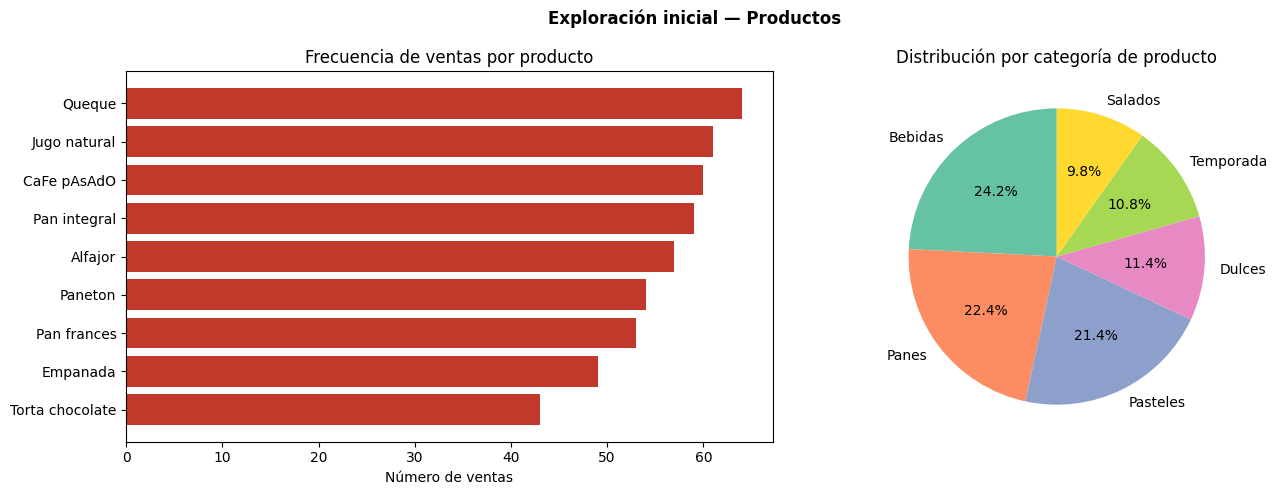

In [12]:
# ── Gráfico 1: Frecuencia de ventas por producto ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Productos
conteo_prod = df['productos_nombre'].value_counts()
axes[0].barh(conteo_prod.index, conteo_prod.values, color='#c0392b')
axes[0].set_xlabel('Número de ventas')
axes[0].set_title('Frecuencia de ventas por producto')
axes[0].invert_yaxis()

# Categorías
conteo_cat = df['productos_categoria'].str.strip().str.capitalize().value_counts()
axes[1].pie(conteo_cat.values, labels=conteo_cat.index, autopct='%1.1f%%',
            startangle=90, colors=plt.cm.Set2.colors)
axes[1].set_title('Distribución por categoría de producto')

plt.suptitle('Exploración inicial — Productos', fontweight='bold')
plt.tight_layout()
plt.show()

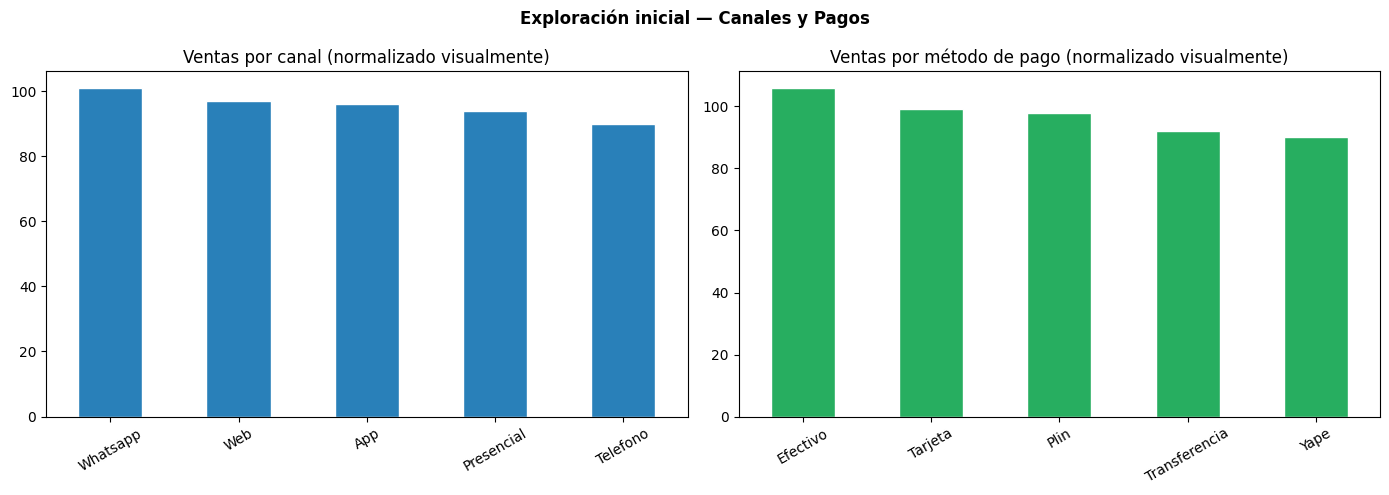

In [13]:
# ── Gráfico 2: Canales y métodos de pago ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Canal normalizado (solo para visualizar)
canal_norm = df['canal'].dropna().str.strip().str.capitalize()
canal_norm.value_counts().plot(kind='bar', ax=axes[0], color='#2980b9', edgecolor='white')
axes[0].set_title('Ventas por canal (normalizado visualmente)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Método de pago normalizado
pago_norm = df['metodo_pago'].dropna().str.strip().str.capitalize()
pago_norm.value_counts().plot(kind='bar', ax=axes[1], color='#27ae60', edgecolor='white')
axes[1].set_title('Ventas por método de pago (normalizado visualmente)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Exploración inicial — Canales y Pagos', fontweight='bold')
plt.tight_layout()
plt.show()

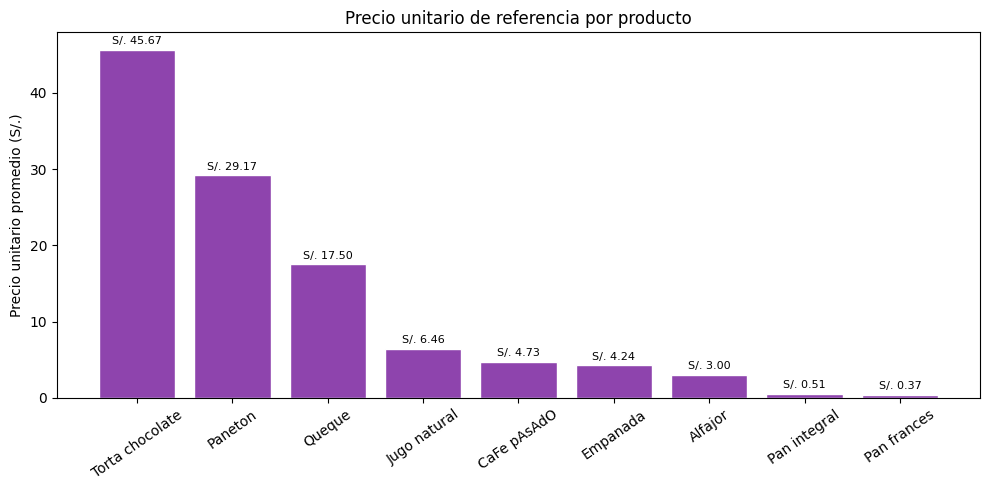

In [14]:
# ── Gráfico 3: Precio unitario de referencia por producto ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
precio_prod = df.groupby('productos_nombre')['productos_precio_unitario'].mean().sort_values(ascending=False)
bars = ax.bar(precio_prod.index, precio_prod.values, color='#8e44ad', edgecolor='white')
ax.set_ylabel('Precio unitario promedio (S/.)')
ax.set_title('Precio unitario de referencia por producto')
ax.tick_params(axis='x', rotation=35)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'S/. {bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### 4.7 Principales hallazgos del EDA

| # | Hallazgo | Detalle |
|---|---|---|
| 1 | **Producto más frecuente** | *Queque* lidera con 64 ventas; *Jugo natural* y *Café pasado* le siguen |
| 2 | **Producto de mayor precio** | *Torta chocolate* (S/. 45.67) y *Panetón* (S/. 29.17) son los más caros |
| 3 | **Zona predominante** | La zona Centro concentra más registros |
| 4 | **Canal predominante** | WhatsApp y Web son los canales con mayor volumen |
| 5 | **Segmentos de cliente** | Se identifican: Premium, Regular, Frecuente, Nuevo, Corporativo — con variantes de escritura |
| 6 | **Columnas numéricas como texto** | precio_unitario, cantidad_unidades e ingreso_venta están guardadas como TEXT |
| 7 | **Locales sin nombre** | 153 registros tienen locales_nombre = NULL (30.6% del total) |

## 5.  Problemas de calidad detectados

### 5.1 Valores nulos

In [15]:
# ── Conteo de nulos por columna ───────────────────────────────────────────────
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

reporte_nulos = pd.DataFrame({
    'columna': nulos.index,
    'nulos': nulos.values,
    'porcentaje (%)': nulos_pct.values
}).query('nulos > 0').sort_values('nulos', ascending=False)

print("Columnas con valores nulos:")
print(reporte_nulos.to_string(index=False))
print(f"\n  La columna más crítica es 'locales_nombre' con {reporte_nulos.iloc[0]['nulos']} nulos ({reporte_nulos.iloc[0]['porcentaje (%)']:.1f}%)")

Columnas con valores nulos:
                columna  nulos  porcentaje (%)
         locales_nombre    153            30.6
            observacion     52            10.4
      clientes_segmento     25             5.0
        clientes_nombre     25             5.0
                  canal     22             4.4
            metodo_pago     15             3.0
           calificacion     11             2.2
        fecha_operacion     10             2.0
          ingreso_venta     10             2.0
               cantidad     10             2.0
          descuento_pct      7             1.4
        precio_unitario      7             1.4
      cantidad_unidades      6             1.2
clientes_fecha_registro      4             0.8
      clientes_distrito      2             0.4

  La columna más crítica es 'locales_nombre' con 153 nulos (30.6%)


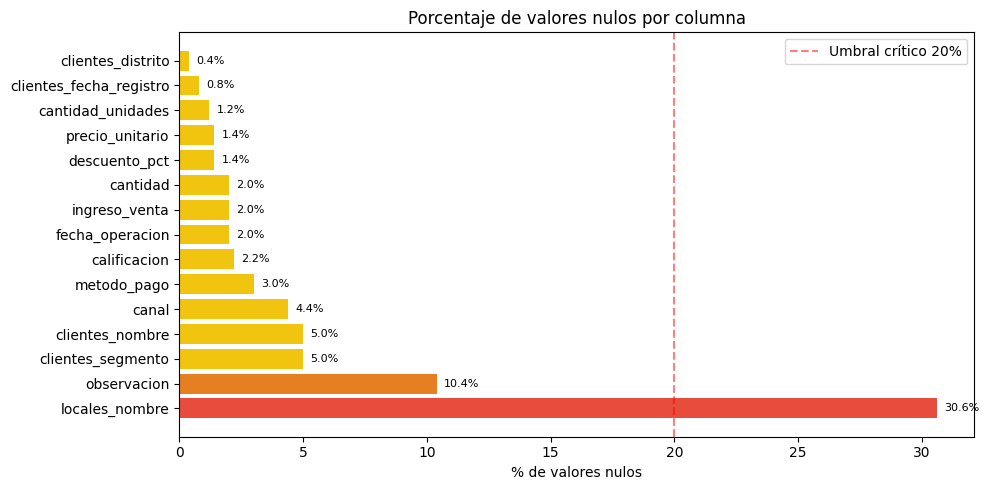

In [16]:
# ── Visualización de nulos ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
cols_con_nulos = reporte_nulos['columna']
pcts = reporte_nulos['porcentaje (%)']
colores = ['#e74c3c' if p > 20 else '#e67e22' if p > 5 else '#f1c40f' for p in pcts]
ax.barh(cols_con_nulos, pcts, color=colores)
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de valores nulos por columna')
ax.axvline(20, color='red', linestyle='--', alpha=0.5, label='Umbral crítico 20%')
ax.legend()
for i, (col, v) in enumerate(zip(cols_con_nulos, pcts)):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 5.2 Registros duplicados

In [17]:
# ── Verificación de duplicados ────────────────────────────────────────────────
dup_total = df.duplicated().sum()
dup_id = df.duplicated(subset='id_venta').sum()

print(f"Filas completamente duplicadas : {dup_total}")
print(f"id_venta duplicados            : {dup_id}")

if dup_total == 0 and dup_id == 0:
    print("\n No se detectaron filas duplicadas ni id_venta repetidos.")

Filas completamente duplicadas : 0
id_venta duplicados            : 0

 No se detectaron filas duplicadas ni id_venta repetidos.


### 5.3 Tipos de datos incorrectos

In [18]:
# ── Columnas que deberían ser numéricas pero son TEXT ─────────────────────────
cols_numericas_problemas = ['precio_unitario', 'cantidad_unidades', 'ingreso_venta', 'descuento_pct']

for col in cols_numericas_problemas:
    intentos = pd.to_numeric(df[col], errors='coerce')
    no_convertibles = intentos.isna().sum() - df[col].isna().sum()
    print(f"  '{col}': tipo actual=TEXT → valores no convertibles directamente: {no_convertibles}")

print("\n  Estas columnas deben convertirse a tipo numérico después de limpiar su contenido.")

  'precio_unitario': tipo actual=TEXT → valores no convertibles directamente: 63
  'cantidad_unidades': tipo actual=TEXT → valores no convertibles directamente: 25
  'ingreso_venta': tipo actual=TEXT → valores no convertibles directamente: 44
  'descuento_pct': tipo actual=TEXT → valores no convertibles directamente: 26

  Estas columnas deben convertirse a tipo numérico después de limpiar su contenido.


### 5.4 Inconsistencias de formato en columnas clave

In [19]:
# ── Problema 1: precio_unitario con coma decimal y espacios ──────────────────
con_coma    = df['precio_unitario'].dropna().str.contains(',', na=False).sum()
con_espacio = df['precio_unitario'].dropna().str.startswith(' ').sum()
print("[precio_unitario]")
print(f"  Valores con coma decimal (ej. '45,67'): {con_coma}")
print(f"  Valores con espacio inicial:             {con_espacio}")
print(f"  Ejemplo problemático: {df[df['precio_unitario'].str.contains(',', na=False)]['precio_unitario'].values[:3]}")

# ── Problema 2: ingreso_venta con prefijos y texto ────────────────────────────
con_soles = df['ingreso_venta'].dropna().str.contains('S/', na=False).sum()
con_aprox = df['ingreso_venta'].dropna().str.contains('aprox', na=False).sum()
print("\n[ingreso_venta]")
print(f"  Valores con prefijo 'S/': {con_soles}")
print(f"  Valores con texto 'aprox': {con_aprox}")
print(f"  Ejemplo: {df[df['ingreso_venta'].str.contains('S/', na=False)]['ingreso_venta'].values[:3]}")

# ── Problema 3: fecha_operacion con múltiples formatos ────────────────────────
fechas = df['fecha_operacion'].dropna()
f_iso    = fechas.str.match(r'^\d{4}-\d{2}-\d{2}$').sum()
f_ddmm   = fechas.str.match(r'^\d{2}-\d{2}-\d{4}$').sum()
f_slash  = fechas.str.contains('/', na=False).sum()
f_espac  = fechas.str.startswith(' ').sum()
print("\n[fecha_operacion]")
print(f"  Formato correcto YYYY-MM-DD  : {f_iso}")
print(f"  Formato invertido DD-MM-YYYY : {f_ddmm}")
print(f"  Con barras '/'               : {f_slash}")
print(f"  Con espacios iniciales       : {f_espac}")

[precio_unitario]
  Valores con coma decimal (ej. '45,67'): 23
  Valores con espacio inicial:             17
  Ejemplo problemático: ['45,67' '45,67' '45,67']

[ingreso_venta]
  Valores con prefijo 'S/': 13
  Valores con texto 'aprox': 10
  Ejemplo: ['S/ 8.31' 'S/ 0.5' 'S/ 35.77']

[fecha_operacion]
  Formato correcto YYYY-MM-DD  : 419
  Formato invertido DD-MM-YYYY : 14
  Con barras '/'               : 34
  Con espacios iniciales       : 23


### 5.5 Inconsistencias de capitalización y espacios

In [20]:
# ── Columnas con muchas variantes por mayúsculas/espacios ─────────────────────
cols_texto = ['canal', 'metodo_pago', 'productos_categoria', 'clientes_segmento']

print("Número de variantes por columna (antes de normalizar):")
print(f"{'Columna':<25} {'Variantes únicas':>15} {'Valores canonicos esperados':>30}")
print("-" * 75)

canonicos = {
    'canal': 'Presencial, WhatsApp, Teléfono, Web, App',
    'metodo_pago': 'Efectivo, Tarjeta, Yape, Plin, Transferencia',
    'productos_categoria': 'Panes, Pasteles, Bebidas, Dulces, Salados, Temporada',
    'clientes_segmento': 'Regular, Premium, Frecuente, Nuevo, Corporativo'
}

for col in cols_texto:
    n_unico = df[col].dropna().nunique()
    canon = canonicos.get(col, '—')
    print(f"{col:<25} {n_unico:>15} {canon:>30}")

Número de variantes por columna (antes de normalizar):
Columna                   Variantes únicas    Valores canonicos esperados
---------------------------------------------------------------------------
canal                                  25 Presencial, WhatsApp, Teléfono, Web, App
metodo_pago                            24 Efectivo, Tarjeta, Yape, Plin, Transferencia
productos_categoria                     8 Panes, Pasteles, Bebidas, Dulces, Salados, Temporada
clientes_segmento                      17 Regular, Premium, Frecuente, Nuevo, Corporativo


### 5.6 Resumen de problemas de calidad detectados

In [21]:
# ── Tabla resumen de problemas ────────────────────────────────────────────────
problemas = [
    ("Valores nulos",            "locales_nombre (30.6%), observacion (10.4%), canal (4.4%)",
     "Imputar o eliminar según impacto"),
    ("Tipos de datos incorrectos", "precio_unitario, cantidad_unidades, ingreso_venta, descuento_pct (TEXT)",
     "Limpiar y convertir a FLOAT / INT"),
    ("Coma como separador decimal", "precio_unitario: 23 registros con coma (ej. '45,67')",
     "Reemplazar ',' por '.' antes de convertir"),
    ("Texto en campos numéricos", "ingreso_venta: 'S/ 0.5', '10.67 aprox'",
     "Extraer solo la parte numérica"),
    ("Múltiples formatos de fecha", "fecha_operacion: YYYY-MM-DD, DD-MM-YYYY, YYYY/MM/DD y con espacios",
     "Unificar a formato ISO YYYY-MM-DD"),
    ("Capitalización inconsistente", "canal, metodo_pago, clientes_segmento, productos_categoria",
     "Normalizar con strip().capitalize()"),
    ("Espacios en valores texto", "'  Web ', '  Presencial ', '  Plin '",
     "Aplicar str.strip() en todas las columnas TEXT"),
    ("Variación en nombres de producto", "'CaFe pAsAdO', 'Pan frances' / 'PaNeS'",
     "Estandarizar nombres canónicos"),
    ("Localidades en minúscula", "clientes_distrito: 'comas', 'lima' (sin capitalizar)",
     "Aplicar str.title() a distritos"),
    ("Nulos en clientes", "clientes_nombre y clientes_segmento: 25 nulos c/u (5%)",
     "Evaluar imputación por categoría mayoritaria"),
]

df_problemas = pd.DataFrame(problemas, columns=['Tipo de problema', 'Descripción / ejemplo', 'Acción sugerida'])
print("=" * 100)
print("RESUMEN DE PROBLEMAS DE CALIDAD DETECTADOS")
print("=" * 100)
print(df_problemas.to_string(index=True))

RESUMEN DE PROBLEMAS DE CALIDAD DETECTADOS
                   Tipo de problema                                                    Descripción / ejemplo                                 Acción sugerida
0                     Valores nulos                locales_nombre (30.6%), observacion (10.4%), canal (4.4%)                Imputar o eliminar según impacto
1        Tipos de datos incorrectos  precio_unitario, cantidad_unidades, ingreso_venta, descuento_pct (TEXT)               Limpiar y convertir a FLOAT / INT
2       Coma como separador decimal                     precio_unitario: 23 registros con coma (ej. '45,67')       Reemplazar ',' por '.' antes de convertir
3         Texto en campos numéricos                                   ingreso_venta: 'S/ 0.5', '10.67 aprox'                  Extraer solo la parte numérica
4       Múltiples formatos de fecha       fecha_operacion: YYYY-MM-DD, DD-MM-YYYY, YYYY/MM/DD y con espacios               Unificar a formato ISO YYYY-MM-DD
5      Capitali

---

## 6.  Conclusiones del checkpoint

### Lo que se logró en esta etapa:

1. **Problema de negocio definido:** Se comprende el contexto de una panadería que necesita estimar ingresos por venta a partir de las unidades vendidas, con miras a planificar producción y promociones.

2. **Base SQLite conectada:** La base se descarga correctamente desde GitHub (panaderia_ventas.db, 500 registros). Contiene una sola tabla no normalizada (ventas_original) con 21 columnas que mezclan datos de cuatro entidades: ventas, clientes, productos y locales.

3. **Exploración inicial completada:** Se identificaron los productos más vendidos (*Queque*, *Jugo natural*, *Café pasado*), los canales principales (WhatsApp, Web), la distribución por zona y los precios de referencia. Se ejecutaron 4 consultas SQL y se produjeron 3 visualizaciones exploratorias.

4. **Problemas de calidad documentados:** Se identificaron 10 tipos de problemas que afectan la calidad de los datos, incluyendo nulos críticos en locales_nombre (30.6%), columnas numéricas almacenadas como texto, múltiples formatos de fecha y capitalización inconsistente en variables categóricas.

### Próximos pasos):
- Limpiar y normalizar las columnas numéricas y de texto
- Unificar formatos de fecha
- Proponer y construir tablas normalizadas
- Guardar el dataset limpio en SQLite
- Entrenar la regresión lineal simple

---
*Checkpoint Semana 6 — Fundamentos de Gestión de Datos · PMD1 · Caso 13: PANADERIA_VENTAS*